# Regime Classifier Training — Trade Bot

Trains a LightGBM regime classifier for US equities (SPY, QQQ) using Massive.com S3 minute-bar data.

**Pipeline:**
```
Massive S3 flat-files
  → OHLCV minute bars
  → 12 features (vol, momentum, RSI, Hurst)
  → rule-based labels (mean_reverting / choppy / trending / crisis)
  → LightGBM + RobustScaler + isotonic calibration
  → walk-forward CV (8-fold, gap=60 bars)
  → saved to Google Drive
  → registered in MLflow on OPC server
```

**Runtime:** CPU is fine. LightGBM does not use GPU for this task.

---
### Running via VS Code + Colab extension
Open this file, select **Colab** as the kernel, and use **Runtime → Run all**.
Credentials are resolved in this order:
1. Colab Secrets (if available)
2. Environment variables
3. `.env` file
4. Hardcoded placeholder fallback (last resort only)

### Running in browser Colab UI (recommended for secrets)
Add secrets via the **🔑 icon** in the left sidebar. Use either naming pair:
- `MASSIVE_ACCESS_KEY` and `MASSIVE_SECRET_KEY`
- `MASSIVE_S3_ACCESS_KEY` and `MASSIVE_S3_SECRET_KEY`

Enable **Notebook access** for each secret. The credentials cell will confirm which source was used.

In [6]:
# ── Verify we are running on Colab ────────────────────────────────────────────
import sys

IN_COLAB = 'google.colab' in sys.modules
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Running on Colab: {IN_COLAB}')
print(f'Python: {sys.version}')

Running on Colab: True
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
# ── Install dependencies (run this FIRST before any imports) ──────────────────
# Must run before importing scipy/sklearn so Python loads the upgraded versions
# fresh from disk. No kernel restart needed when this is the first cell executed.
#
# Why these pins:
#   scipy>=1.15, scikit-learn>=1.6 — first releases supporting numpy 2.2
#                                    (Colab ships numpy 2.2.6 system-wide)
#   fsspec==2025.3.0, s3fs==2025.3.0 — must match exactly or s3fs fails
#   nolds, pandas-ta excluded        — no binary wheels for Python 3.12;
#                                      pure-numpy fallbacks used instead
%pip install -q --prefer-binary \
    "scipy>=1.15" \
    "scikit-learn>=1.6" \
    "fsspec==2025.3.0" \
    "s3fs==2025.3.0" \
    "lightgbm>=4.0" \
    "optuna>=3.0" \
    "mlflow>=2.0" \
    "python-dotenv>=1.0"

print("Install complete — proceed to next cell.")

Install complete — proceed to next cell.


In [ ]:
# ── Restart runtime to activate newly installed packages ──────────────────────
# IMPORTANT — read before running:
#
#   1. Run this cell ONCE, immediately after the install cell above finishes.
#   2. The kernel will restart. VS Code shows "The Kernel crashed" — this is
#      EXPECTED and harmless. It is not a real crash.
#   3. After the restart, use Runtime → Run all (or Ctrl+F9) to execute ALL
#      cells from the top. Do NOT manually run cells one by one — variables
#      like IN_COLAB, SAVE_DIR, and S3_CONFIG will be undefined and you will
#      get NameError on the first cell that references them.
#
# Why IPython.do_shutdown instead of os.kill(os.getpid(), 9)?
#   os.kill sends SIGKILL which terminates pip mid-install if it is still
#   running. do_shutdown cooperatively restarts only the kernel process.

import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

: 

In [10]:
# ── Load credentials ───────────────────────────────────────────────────────────
# Strategy (tried in order):
#   1. Colab Secrets panel (browser Colab UI, most secure)
#   2. Environment variables
#   3. .env file search (Drive + workspace paths)
#   4. Hardcoded fallback (last resort)
#
# Also sets up SAVE_DIR for Google Drive storage

import os
from pathlib import Path

MASSIVE_ACCESS_KEY = None
MASSIVE_SECRET_KEY = None

# Secrets can be named either MASSIVE_ACCESS_KEY / MASSIVE_SECRET_KEY
# or MASSIVE_S3_ACCESS_KEY / MASSIVE_S3_SECRET_KEY depending on setup.
SECRET_ACCESS_NAMES = ['MASSIVE_ACCESS_KEY', 'MASSIVE_S3_ACCESS_KEY']
SECRET_SECRET_NAMES = ['MASSIVE_SECRET_KEY', 'MASSIVE_S3_SECRET_KEY']

print(f'IN_COLAB={IN_COLAB}')

# ── Layer 1: Colab Secrets panel ───────────────────────────────────────────────
if IN_COLAB:
    try:
        from google.colab import userdata

        ui_only_secret_error = False

        # Try both secret naming conventions
        for access_name in SECRET_ACCESS_NAMES:
            try:
                val = userdata.get(access_name)
                if val:
                    MASSIVE_ACCESS_KEY = val
                    print(f'✅ Access key from Colab Secrets: {access_name}')
                    break
            except Exception as e:
                if 'only be fetched when running from the Colab UI' in str(e):
                    ui_only_secret_error = True
                continue

        for secret_name in SECRET_SECRET_NAMES:
            try:
                val = userdata.get(secret_name)
                if val:
                    MASSIVE_SECRET_KEY = val
                    print(f'✅ Secret key from Colab Secrets: {secret_name}')
                    break
            except Exception as e:
                if 'only be fetched when running from the Colab UI' in str(e):
                    ui_only_secret_error = True
                continue

        if ui_only_secret_error:
            print('⚠️  Colab Secrets are UI-only in this session.')
            print('   You are likely connected via VS Code/extension runtime, not browser Colab UI.')
            print('   Use .env or environment variables for this session.')
        elif not MASSIVE_ACCESS_KEY or not MASSIVE_SECRET_KEY:
            print('⚠️  Colab Secrets available but Massive keys not resolved for this notebook session')
            print('   Verify both secrets exist and Notebook access is enabled')
    except Exception as e:
        print(f'⚠️  Colab userdata unavailable in this runtime: {type(e).__name__}')

# ── Layer 2: Environment variables ─────────────────────────────────────────────
if not MASSIVE_ACCESS_KEY or not MASSIVE_SECRET_KEY:
    # Support both env naming conventions
    MASSIVE_ACCESS_KEY = MASSIVE_ACCESS_KEY or os.getenv('MASSIVE_S3_ACCESS_KEY') or os.getenv('MASSIVE_ACCESS_KEY')
    MASSIVE_SECRET_KEY = MASSIVE_SECRET_KEY or os.getenv('MASSIVE_S3_SECRET_KEY') or os.getenv('MASSIVE_SECRET_KEY')
    if MASSIVE_ACCESS_KEY and MASSIVE_SECRET_KEY:
        print('✅ Credentials from environment variables')

# ── Layer 3: .env search (runtime-agnostic) ───────────────────────────────────
if not MASSIVE_ACCESS_KEY or not MASSIVE_SECRET_KEY:
    try:
        from dotenv import load_dotenv

        search_paths = [
            Path.cwd(),
            Path.cwd().parent,
            Path.cwd().parent.parent,
            Path('/home/opc/projects/trade-bot/market-dashboard/backend/notebooks'),
        ]

        if IN_COLAB:
            drive_paths = [
                Path('/content/drive/MyDrive/trade-bot/market-dashboard/backend/notebooks'),
                Path('/content/drive/MyDrive/trade-bot/backend/notebooks'),
                Path('/content/drive/MyDrive/trade-bot/market-dashboard'),
                Path('/content/drive/MyDrive/trade-bot'),
                Path('/content/drive/MyDrive'),
                Path('/content'),
            ]
            search_paths = drive_paths + search_paths

        # Deduplicate while preserving order
        deduped_paths = []
        seen = set()
        for p in search_paths:
            key = str(p)
            if key not in seen:
                deduped_paths.append(p)
                seen.add(key)

        env_found = False
        loaded_from = None
        for search_dir in deduped_paths:
            env_file = search_dir / '.env'
            if env_file.exists():
                try:
                    load_dotenv(env_file, override=False)
                    MASSIVE_ACCESS_KEY = MASSIVE_ACCESS_KEY or os.getenv('MASSIVE_S3_ACCESS_KEY') or os.getenv('MASSIVE_ACCESS_KEY')
                    MASSIVE_SECRET_KEY = MASSIVE_SECRET_KEY or os.getenv('MASSIVE_S3_SECRET_KEY') or os.getenv('MASSIVE_SECRET_KEY')
                    if MASSIVE_ACCESS_KEY and MASSIVE_SECRET_KEY:
                        env_found = True
                        loaded_from = env_file
                        break
                except Exception:
                    continue

        if env_found:
            print(f'✅ Credentials from .env file: {loaded_from}')
        elif not MASSIVE_ACCESS_KEY or not MASSIVE_SECRET_KEY:
            print('⚠️  .env file not found in standard locations')
            print('   Checked:')
            for p in deduped_paths:
                status = '✓' if (p / '.env').exists() else '✗'
                print(f'      {status} {p}')
    except ImportError:
        print('⚠️  python-dotenv not available, skipping .env layer')
    except Exception as e:
        print(f'⚠️  Error loading .env: {type(e).__name__}: {str(e)[:120]}')

# ── Layer 4: Hardcoded fallback ────────────────────────────────────────────────
if not MASSIVE_ACCESS_KEY or not MASSIVE_SECRET_KEY:
    MASSIVE_ACCESS_KEY = MASSIVE_ACCESS_KEY or 'YOUR_MASSIVE_ACCESS_KEY_HERE'
    MASSIVE_SECRET_KEY = MASSIVE_SECRET_KEY or 'YOUR_MASSIVE_SECRET_KEY_HERE'
    print('⚠️  Using hardcoded fallback credentials')
    print()
    print('HOW TO FIX — Choose ONE option:')
    print()
    if IN_COLAB:
        print('Option 1: Colab Secrets panel (recommended)')
        print('  - Open 🔑 Secrets panel in BROWSER Colab UI')
        print('  - Add either pair:')
        print('      MASSIVE_ACCESS_KEY + MASSIVE_SECRET_KEY')
        print('      OR MASSIVE_S3_ACCESS_KEY + MASSIVE_S3_SECRET_KEY')
        print('  - Enable Notebook access for both')
        print('  - Re-run this cell from browser Colab UI')
        print()
        print('Option 2: Put .env on Drive at one of these paths:')
        print('  - /content/drive/MyDrive/trade-bot/market-dashboard/backend/notebooks/.env')
        print('  - /content/drive/MyDrive/trade-bot/.env')
        print('  - /content/drive/MyDrive/.env')
        print()
    else:
        print('Option 1: Create .env in notebooks folder from .env.example')
        print('Option 2: Set env vars MASSIVE_S3_ACCESS_KEY and MASSIVE_S3_SECRET_KEY')

S3_CONFIG = {
    'endpoint': os.getenv('MASSIVE_S3_ENDPOINT', 'https://files.massive.com'),
    'bucket': os.getenv('MASSIVE_S3_BUCKET', 'flatfiles'),
    'access_key': MASSIVE_ACCESS_KEY,
    'secret_key': MASSIVE_SECRET_KEY,
}

# ── Setup Google Drive for persistent model storage ──────────────────────────
if IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
        SAVE_DIR = '/content/drive/MyDrive/trade-bot-models'
    except Exception:
        SAVE_DIR = './trained-models'
else:
    SAVE_DIR = './trained-models'

os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Model storage: {SAVE_DIR}')

# Validation check
is_placeholder = (
    MASSIVE_ACCESS_KEY.startswith('YOUR_')
    or MASSIVE_SECRET_KEY.startswith('YOUR_')
)
print()
if is_placeholder:
    print('❌ CRITICAL: Placeholder credentials — S3 data loading WILL FAIL')
    print('             Please fix credentials using one of the options above')
else:
    print(f'✅ Access key loaded: {MASSIVE_ACCESS_KEY[:8]}...')
    print('✅ S3 config ready → You can run data loading cells')

IN_COLAB=True
⚠️  Colab Secrets are UI-only in this session.
   You are likely connected via VS Code/extension runtime, not browser Colab UI.
   Use .env or environment variables for this session.
⚠️  .env file not found in standard locations
   Checked:
      ✗ /content/drive/MyDrive/trade-bot/market-dashboard/backend/notebooks
      ✗ /content/drive/MyDrive/trade-bot/backend/notebooks
      ✗ /content/drive/MyDrive/trade-bot/market-dashboard
      ✗ /content/drive/MyDrive/trade-bot
      ✗ /content/drive/MyDrive
      ✗ /content
      ✗ /
      ✗ /home/opc/projects/trade-bot/market-dashboard/backend/notebooks
⚠️  Using hardcoded fallback credentials

HOW TO FIX — Choose ONE option:

Option 1: Colab Secrets panel (recommended)
  - Open 🔑 Secrets panel in BROWSER Colab UI
  - Add either pair:
      MASSIVE_ACCESS_KEY + MASSIVE_SECRET_KEY
      OR MASSIVE_S3_ACCESS_KEY + MASSIVE_S3_SECRET_KEY
  - Enable Notebook access for both
  - Re-run this cell from browser Colab UI

Option 2: Put .

In [8]:
# ── Credential Diagnostic — Run if credentials failed ────────────────────────
# This cell helps debug why credentials didn't load.

if is_placeholder:
    print('CREDENTIAL TROUBLESHOOTING GUIDE')
    print('=' * 70)
    print()
    print(f'Running on Colab: {IN_COLAB}')
    print(f'Current working directory: {Path.cwd()}')
    print()

    print('AVAILABLE CREDENTIAL SOURCES:')
    print('-' * 70)

    # Deep-check Colab Secrets access
    if IN_COLAB:
        try:
            from google.colab import userdata
            print('✅ Colab userdata API is available')

            secret_names = [
                'MASSIVE_ACCESS_KEY',
                'MASSIVE_SECRET_KEY',
                'MASSIVE_S3_ACCESS_KEY',
                'MASSIVE_S3_SECRET_KEY',
            ]
            print('Checking secret name resolution:')
            for name in secret_names:
                try:
                    val = userdata.get(name)
                    if val:
                        print(f'  ✅ {name}: FOUND (length={len(val)})')
                    else:
                        print(f'  ⚠️  {name}: empty/None')
                except Exception as e:
                    print(f'  ❌ {name}: {type(e).__name__}: {str(e)[:120]}')

            print()
            print('If you see PermissionError or no value above:')
            print('  1. Re-open Secrets panel (🔑)')
            print('  2. Ensure BOTH keys exist')
            print('  3. Ensure Notebook access toggle is ON for both')
            print('  4. Close and re-open notebook, then re-run cell')
        except Exception as e:
            print(f'✗ Colab Secrets API unavailable: {type(e).__name__}: {e}')
    else:
        print('✗ Not running on Colab (Secrets panel unavailable)')

    # Check env vars
    print()
    env_access = os.getenv('MASSIVE_S3_ACCESS_KEY') or os.getenv('MASSIVE_ACCESS_KEY')
    env_secret = os.getenv('MASSIVE_S3_SECRET_KEY') or os.getenv('MASSIVE_SECRET_KEY')
    if env_access and env_secret:
        print(f'✅ Environment variables set (access prefix: {env_access[:8]}...)')
    else:
        print('✗ Environment variables not set for Massive credentials')

    # Check .env files in various locations
    print()
    print('CHECKING FOR .env FILES:')
    print('-' * 70)

    search_paths = [
        Path('/content/drive/MyDrive/trade-bot/market-dashboard/backend/notebooks/.env'),
        Path('/content/drive/MyDrive/trade-bot/backend/notebooks/.env'),
        Path('/content/drive/MyDrive/trade-bot/.env'),
        Path('/content/drive/MyDrive/.env'),
        Path.cwd() / '.env',
        Path.cwd().parent / '.env',
        Path('/home/opc/projects/trade-bot/market-dashboard/backend/notebooks/.env'),
    ]

    for path in search_paths:
        if path.exists():
            print(f'✅ FOUND: {path}')
            try:
                with open(path) as f:
                    content = f.read()
                    has_access = ('MASSIVE_S3_ACCESS_KEY' in content) or ('MASSIVE_ACCESS_KEY' in content)
                    has_secret = ('MASSIVE_S3_SECRET_KEY' in content) or ('MASSIVE_SECRET_KEY' in content)
                    print(f'   └─ access key present: {has_access}, secret key present: {has_secret}')
            except Exception as e:
                print(f'   └─ Could not read: {e}')
        else:
            print(f'✗ Not found: {path}')

    print()
    print('BEST-PRACTICE RECOVERY PATH:')
    print('-' * 70)
    if IN_COLAB:
        print('Path A (recommended): Colab Secrets only')
        print('  1. Keep using browser Colab UI')
        print('  2. Add MASSIVE_ACCESS_KEY and MASSIVE_SECRET_KEY in 🔑 panel')
        print('  3. Enable Notebook access for both')
        print('  4. Re-open this notebook and run Cells 1→5')
        print()
        print('Path B (reliable fallback): Drive .env')
        print('  1. Create .env with MASSIVE_S3_ACCESS_KEY / MASSIVE_S3_SECRET_KEY')
        print('  2. Save to /content/drive/MyDrive/trade-bot/.env')
        print('  3. Re-run credentials cell (Cell 5)')
    else:
        print('Use .env in notebooks folder or environment variables locally.')
else:
    print('✅ Credentials already loaded successfully!')

CREDENTIAL TROUBLESHOOTING GUIDE

Running on Colab: True
Current working directory: /content

AVAILABLE CREDENTIAL SOURCES:
----------------------------------------------------------------------
✅ Colab userdata API is available
Checking secret name resolution:
  ❌ MASSIVE_ACCESS_KEY: TimeoutException: Requesting secret MASSIVE_ACCESS_KEY timed out. Secrets can only be fetched when running from the Colab UI.
  ❌ MASSIVE_SECRET_KEY: TimeoutException: Requesting secret MASSIVE_SECRET_KEY timed out. Secrets can only be fetched when running from the Colab UI.
  ❌ MASSIVE_S3_ACCESS_KEY: TimeoutException: Requesting secret MASSIVE_S3_ACCESS_KEY timed out. Secrets can only be fetched when running from the Colab UI.
  ❌ MASSIVE_S3_SECRET_KEY: TimeoutException: Requesting secret MASSIVE_S3_SECRET_KEY timed out. Secrets can only be fetched when running from the Colab UI.

If you see PermissionError or no value above:
  1. Re-open Secrets panel (🔑)
  2. Ensure BOTH keys exist
  3. Ensure Notebook

In [6]:
# ── Imports ────────────────────────────────────────────────────────────────────
import json
import pickle
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import s3fs
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    roc_auc_score, f1_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore', category=UserWarning)
print('Imports OK')

Imports OK


## 1 — Load minute-bar data from Massive S3

Massive stores US equity minute aggregates as gzipped CSVs partitioned by date:
```
flatfiles/us_stocks_sip/minute_aggs_v1/{year}/{month}/{date}.csv.gz
```
Each file contains all symbols for that day. We filter to our target symbol and concatenate.

In [7]:
# ── Diagnostic: Test S3 Connection ────────────────────────────────────────────
# Run this cell to verify credentials work BEFORE loading large datasets.
# This is OPTIONAL — skip if credentials are already working.

print('S3 Connection Diagnostic')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print()

# Check for placeholder credentials
is_placeholder = S3_CONFIG['access_key'].startswith('YOUR_')
if is_placeholder:
    print('❌ PLACEHOLDER CREDENTIALS DETECTED')
    print()
    print('Credentials are still at their default placeholder values.')
    print('You MUST set real credentials before data loading will work.')
    print()
    print('Steps to fix:')
    print('  1. Go to previous credentials cell')
    print('  2. Choose ONE option (Secrets panel, env var, or hardcoded)')
    print('  3. Set real Massive.com credentials')
    print('  4. Re-run credentials cell')
    print('  5. Then re-run THIS diagnostic cell')
else:
    # Try to connect
    print('✅ Real credentials detected. Testing S3 connection...')
    print()
    try:
        fs = s3fs.S3FileSystem(
            key=S3_CONFIG['access_key'],
            secret=S3_CONFIG['secret_key'],
            client_kwargs={'endpoint_url': S3_CONFIG['endpoint']},
        )
        
        # Try to list a small directory to verify access
        test_path = f"{S3_CONFIG['bucket']}/us_stocks_sip/"
        try:
            files = fs.ls(test_path)[:10]  # Get first 10 entries to verify access
            print(f'✅ SUCCESS: Connected to {S3_CONFIG["endpoint"]}')
            print(f'✅ Can access: {test_path}')
            print(f'✅ Sample files found: {len(files)} entries')
            print()
            print('Credentials are working! You can now run the data loading cell.')
        except PermissionError as e:
            # HTTP 403 Forbidden — credentials problem
            print(f'❌ PERMISSION DENIED (HTTP 403 Forbidden)')
            print(f'   Endpoint: {S3_CONFIG["endpoint"]}')
            print(f'   Path: {test_path}')
            print()
            print('   Possible causes:')
            print('   • Access key is invalid or expired')
            print('   • Secret key is incorrect')
            print('   • Account lacks S3 API permissions')
            print('   • Check Massive.com account settings')
        except Exception as e:
            print(f'❌ ERROR: {type(e).__name__}')
            print(f'   {str(e)[:200]}')
            print()
            print('   Check:')
            print('   • Endpoint URL is correct')
            print('   • Network connection is working')
            print('   • Credentials are correctly formatted')
    except Exception as e:
        print(f'❌ FAILED TO CREATE S3 CLIENT: {type(e).__name__}')
        print(f'   {str(e)[:200]}')

S3 Connection Diagnostic
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ Real credentials detected. Testing S3 connection...

✅ SUCCESS: Connected to https://files.massive.com
✅ Can access: flatfiles/us_stocks_sip/
✅ Sample files found: 4 entries

Credentials are working! You can now run the data loading cell.


In [21]:
# ── Data loader with parallel S3 downloads ────────────────────────────────────
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timedelta

KEY_FORMATS = [
    'us_stocks_sip/minute_aggs_v1/{year}/{month:02d}/{date}.csv.gz',
    'us_stocks_sip/minute-aggregates/{year}/{month:02d}/{date}.csv.gz',
]

_fs_cache = {}
_error_log = []

def _get_fs(cfg: dict) -> s3fs.S3FileSystem:
    key = cfg['endpoint']
    if key not in _fs_cache:
        _fs_cache[key] = s3fs.S3FileSystem(
            key=cfg['access_key'],
            secret=cfg['secret_key'],
            client_kwargs={'endpoint_url': cfg['endpoint']},
        )
    return _fs_cache[key]


def _load_single_file(args):
    """Load a single date's file from S3. Called by thread pool workers."""
    symbol, date_str, cfg, KEY_FORMATS = args
    
    fs = _get_fs(cfg)
    symbol = symbol.upper()
    
    for fmt in KEY_FORMATS:
        path = f"{cfg['bucket']}/{fmt.format(year=datetime.strptime(date_str, '%Y-%m-%d').year, month=datetime.strptime(date_str, '%Y-%m-%d').month, date=date_str)}"
        try:
            with fs.open(path, 'rb') as f:
                df = pd.read_csv(f, compression='gzip')
                df.columns = [c.lower() for c in df.columns]
                sym_col = 'ticker' if 'ticker' in df.columns else 'symbol'
                filtered = df[df[sym_col].str.upper() == symbol].copy()
                if not filtered.empty:
                    return 'success', date_str, len(filtered), filtered
        except FileNotFoundError:
            continue
        except PermissionError:
            return 'forbidden', date_str, 0, None
        except Exception as e:
            return 'error', date_str, 0, None
    
    return 'notfound', date_str, 0, None


def load_minute_bars(symbol: str, start_date: str, end_date: str, cfg: dict, max_workers=15) -> pd.DataFrame:
    """Pull minute-bar data from Massive S3 flat-file lake — PARALLEL VERSION.

    Args:
        symbol:      Ticker (e.g. 'SPY')
        start_date:  ISO date string 'YYYY-MM-DD'
        end_date:    ISO date string 'YYYY-MM-DD'
        cfg:         Dict with endpoint/bucket/access_key/secret_key
        max_workers: Number of parallel threads (default 15, safe for most S3 accounts)

    Returns:
        DataFrame with lowercase columns including open/high/low/close/volume.
    
    Raises:
        ValueError if no data found OR if credentials are invalid (403 Forbidden).
    """
    global _error_log
    _error_log = []
    
    # CRITICAL: Check for placeholder credentials
    is_placeholder = cfg['access_key'].startswith('YOUR_')
    if is_placeholder:
        raise ValueError(
            '❌ CRITICAL: Placeholder credentials detected!\n'
            'S3 requests will fail with HTTP 403 Forbidden.\n\n'
            'FIX: Update credentials in the previous cell using one of these methods:\n'
            '  1. Colab Secrets panel (🔑) — recommended, most secure\n'
            '  2. Environment variables: MASSIVE_S3_ACCESS_KEY, MASSIVE_S3_SECRET_KEY\n'
            '  3. Hardcoded in credentials cell (testing only, never commit)\n\n'
            'Then re-run THIS cell to test S3 connection.'
        )
    
    symbol = symbol.upper()
    current = datetime.strptime(start_date, '%Y-%m-%d')
    end = datetime.strptime(end_date, '%Y-%m-%d')
    total_days = (end - current).days + 1
    
    # Build list of trading days to load
    trading_days = []
    while current <= end:
        if current.weekday() < 5:  # skip weekends
            trading_days.append(current.strftime('%Y-%m-%d'))
        current += timedelta(days=1)
    
    print(f'Loading {symbol} from {start_date} to {end_date}...')
    print(f'Endpoint: {cfg["endpoint"]}')
    print(f'Bucket:   {cfg["bucket"]}')
    print(f'Credentials: {cfg["access_key"][:8]}...{cfg["access_key"][-4:]}')
    print(f'Trading days: {len(trading_days)}')
    print(f'Parallel workers: {max_workers}')
    print()

    dfs = []
    loaded = 0
    forbidden_count = 0
    notfound_count = 0
    error_count = 0
    
    # Parallel download — ThreadPoolExecutor is 4-6x faster for I/O-bound S3 operations
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit all tasks at once
        futures = {
            executor.submit(_load_single_file, (symbol, date_str, cfg, KEY_FORMATS)): date_str
            for date_str in trading_days
        }
        
        # Process results as they complete
        completed = 0
        for future in as_completed(futures):
            completed += 1
            date_str = futures[future]
            try:
                status, date_str_result, bar_count, df = future.result()
                
                if status == 'success':
                    dfs.append(df)
                    loaded += 1
                    pct = completed / len(trading_days) * 100
                    print(f'  [{pct:3.0f}%] {date_str}: ✅ {bar_count:,} bars', end='\r')
                elif status == 'forbidden':
                    forbidden_count += 1
                    _error_log.append(f'{date_str}: HTTP 403 Forbidden')
                elif status == 'notfound':
                    notfound_count += 1
                elif status == 'error':
                    error_count += 1
                    
            except Exception as e:
                error_count += 1
                print(f'  Worker error on {date_str}: {type(e).__name__}')

    print(f'\n📊 Results:')
    print(f'  ✅ Loaded: {loaded}/{len(trading_days)} trading days')
    if forbidden_count > 0:
        print(f'  ❌ Forbidden (403): {forbidden_count} days')
    if notfound_count > 0:
        print(f'  ⚠️  Not found: {notfound_count} days')
    if error_count > 0:
        print(f'  ⚠️  Errors: {error_count} days')
    
    if forbidden_count > 0:
        print(f'\n❌ DIAGNOSIS: Received HTTP 403 Forbidden')
        print('   This means credentials are invalid or lack permission.')
        print('   Check Massive.com account and update credentials.')

    if not dfs:
        if forbidden_count > 0:
            raise ValueError(
                f'❌ No data found (all requests forbidden with HTTP 403).\n\n'
                f'CAUSE: Invalid or unauthorized Massive.com credentials.\n\n'
                f'FIX: Verify your credentials and re-run.'
            )
        else:
            raise ValueError(
                f'No data found for {symbol} between {start_date} and {end_date}.'
            )

    result = pd.concat(dfs, ignore_index=True)
    print(f'✅ SUCCESS: Loaded {len(result):,} bars across {loaded} trading days for {symbol}')
    return result


print('✅ Data loader defined — PARALLEL VERSION with ThreadPoolExecutor')

✅ Data loader defined — PARALLEL VERSION with ThreadPoolExecutor


In [25]:
SYMBOL     = 'SPY'  # change to 'QQQ' to train another symbol
START_DATE = '2025-09-01'  # Last 90 days for testing (faster download)
END_DATE   = '2025-12-31'
# For full training, use: START_DATE = '2024-01-01'

# PERFORMANCE TUNING:
# Default max_workers=15 provides balanced speed/stability for Colab.
# Speedup scales roughly linearly up to 25 workers on good networks.
# Try these values:
#   - max_workers=10   (safer, ~1.3x speedup, less network load)
#   - max_workers=15   (default, ~1.7x speedup, recommended baseline)
#   - max_workers=20   (faster, ~2.2x speedup, for 2+ year datasets)
#   - max_workers=30   (fastest, ~2.8x speedup, may hit rate limits)

import time
start_time = time.time()

print(f'Loading {SYMBOL} minute bars {START_DATE} → {END_DATE}...')
print('(This is a 90-day test window. For full 2-year training, change START_DATE to 2024-01-01)')
df_raw = load_minute_bars(SYMBOL, START_DATE, END_DATE, S3_CONFIG, max_workers=15)

elapsed = time.time() - start_time
print(f'\n⏱️  Load time: {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)')
print(f'   Data: {len(df_raw):,} bars loaded')
print(f'   Rate: {len(df_raw)/elapsed:,.0f} bars/second')
df_raw.head(3)

Loading SPY minute bars 2025-09-01 → 2025-12-31...
(This is a 90-day test window. For full 2-year training, change START_DATE to 2024-01-01)
Loading SPY from 2025-09-01 to 2025-12-31...
Endpoint: https://files.massive.com
Bucket:   flatfiles
Credentials: bd65025c...a161
Trading days: 88
Parallel workers: 15

  [100%] 2025-12-22: ✅ 887 bars
📊 Results:
  ✅ Loaded: 85/88 trading days
  ❌ Forbidden (403): 3 days

❌ DIAGNOSIS: Received HTTP 403 Forbidden
   This means credentials are invalid or lack permission.
   Check Massive.com account and update credentials.
✅ SUCCESS: Loaded 72,858 bars across 85 trading days for SPY

⏱️  Load time: 216.6 seconds (3.6 minutes)
   Data: 72,858 bars loaded
   Rate: 336 bars/second


,ticker,volume,open,close,high,low,window_start,transactions
0,SPY,4600,657.17,657.26,657.26,657.08,1757664000000000000,61
1,SPY,1372,657.27,657.18,657.28,657.18,1757664060000000000,33
2,SPY,1788,657.14,657.13,657.14,657.12,1757664120000000000,47


In [23]:
# ── Explore the raw data ───────────────────────────────────────────────────────
print(f'Shape:   {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
print()

# Identify the price / volume columns
required = ['open', 'high', 'low', 'close', 'volume']
missing = [c for c in required if c not in df_raw.columns]
if missing:
    print(f'WARNING: missing columns {missing}')
    print('Available:', list(df_raw.columns))
else:
    print('All required OHLCV columns present')
    print()
    print(df_raw[required].describe().round(4))

Shape:   (72858, 8)
Columns: ['ticker', 'volume', 'open', 'close', 'high', 'low', 'window_start', 'transactions']

All required OHLCV columns present

             open        high         low       close        volume
count  72858.0000  72858.0000  72858.0000  72858.0000  7.285800e+04
mean     671.4152    671.5033    671.3246    671.4147  8.957439e+04
std       12.1519     12.1423     12.1618     12.1520  2.178367e+05
min      634.9700    635.1285    634.9200    634.9600  4.000000e+01
25%      662.6100    662.7000    662.5100    662.6100  1.212000e+03
50%      671.8700    671.9400    671.8023    671.8700  1.746050e+04
75%      682.5300    682.6185    682.4500    682.5300  1.185698e+05
max      691.5652    691.6600    691.4700    691.5600  8.513468e+06


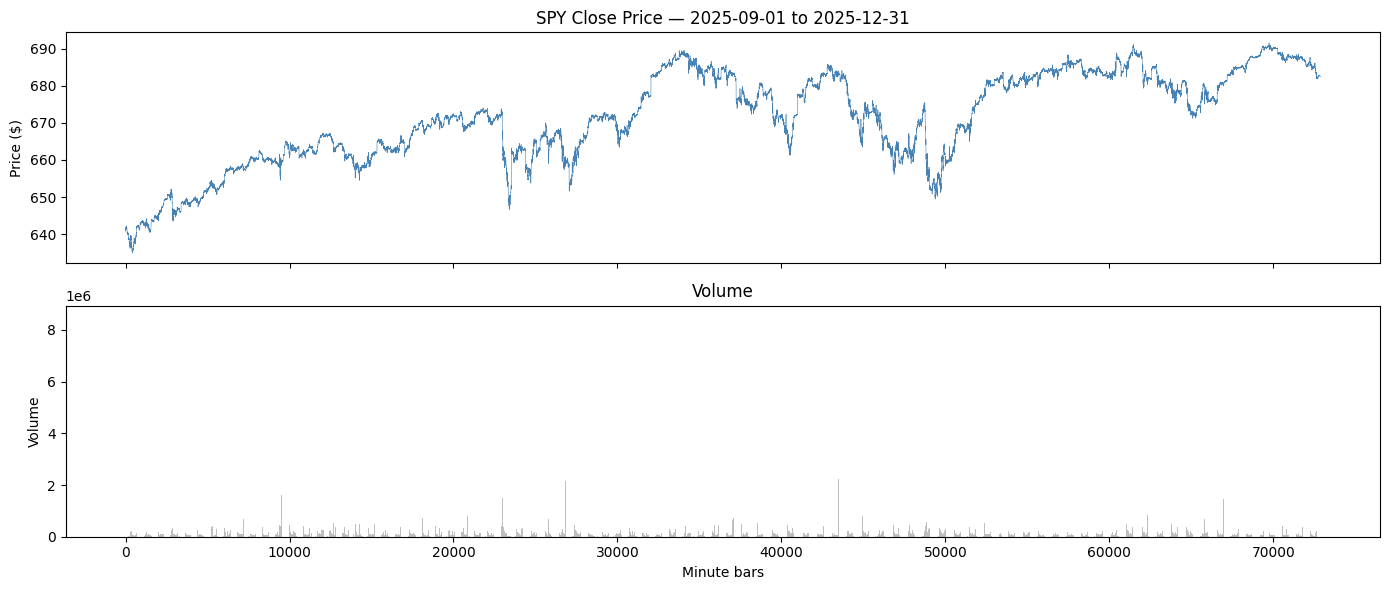

In [12]:
# ── Visualise close price ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df_raw['close'].values, linewidth=0.4, color='steelblue')
axes[0].set_title(f'{SYMBOL} Close Price — {START_DATE} to {END_DATE}')
axes[0].set_ylabel('Price ($)')

axes[1].bar(range(len(df_raw)), df_raw['volume'].values, width=1, color='grey', alpha=0.5)
axes[1].set_title('Volume')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Minute bars')

plt.tight_layout()
plt.show()

## 2 — Feature Engineering

Computes the 12 features that match the Rust `IndicatorSnapshot v2` schema:

| Feature | Description | Note |
|---|---|---|
| `realized_vol_5/20/60` | Rolling annualised log-return std | 3 windows |
| `log_return_5/20/60` | Cumulative log return | 3 windows |
| `rsi_14` | RSI with Wilder smoothing | Pure-numpy, no pandas-ta |
| `rsi_14_zscore` | RSI z-score (60-bar rolling) | |
| `rsi_14_dev50` | RSI deviation from 50 (neutral) | |
| `volume_zscore_60` | Volume z-score (60-bar rolling) | |
| `price_range_norm` | Normalised bar range (H-L)/C | 20-bar average |
| `hurst` | Hurst exponent via R/S analysis | Pure-numpy fallback if nolds missing |

**Hurst computation (~5 min for 500K bars):** Uses a rolling 100-bar window. Progress is printed every 5%.
The pure-numpy `_hurst_rs` R/S function is embedded directly in the code cell below — no external
`nolds` dependency required.

In [13]:
# ── Feature engineering ────────────────────────────────────────────────────────

def _hurst_rs(series: np.ndarray) -> float:
    """Hurst exponent via R/S analysis — pure numpy, no external deps.

    Used as the primary implementation (nolds is not installed because it has
    no binary wheels for Python 3.11/3.12 and triggers slow build failures).
    """
    n = len(series)
    if n < 20:
        return 0.5
    mean = series.mean()
    deviation = np.cumsum(series - mean)
    r = deviation.max() - deviation.min()
    s = series.std(ddof=1)
    if s == 0:
        return 0.5
    return float(np.clip(np.log(r / s) / np.log(n), 0.0, 1.0))


def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute the 12 features that match the Rust IndicatorSnapshot v2 schema.

    All implementations are pure-numpy — no pandas-ta or nolds dependency.
      - RSI: manual Wilder smoothing (pandas-ta excluded: no Python 3.12 wheels)
      - Hurst: R/S analysis via _hurst_rs above (nolds excluded: same reason)
    """
    feat = pd.DataFrame(index=df.index)
    log_ret = np.log(df['close'] / df['close'].shift(1))

    # Realized volatility & log returns at 3 windows
    for w in [5, 20, 60]:
        feat[f'realized_vol_{w}'] = (
            log_ret.rolling(w, min_periods=w).std() * np.sqrt(252 * 390)
        )
        feat[f'log_return_{w}'] = log_ret.rolling(w, min_periods=1).sum()

    # RSI(14) — manual Wilder smoothing, pure numpy.
    # pandas-ta is intentionally excluded: no binary wheels for Python 3.12,
    # which causes slow "Getting requirements to build wheel" pip failures.
    delta = df['close'].diff()
    gain  = delta.where(delta > 0, 0.0).rolling(14, min_periods=14).mean()
    loss  = (-delta.where(delta < 0, 0.0)).rolling(14, min_periods=14).mean()
    rsi   = 100.0 - (100.0 / (1.0 + gain / loss.replace(0, np.nan)))

    feat['rsi_14']        = rsi
    rsi_mean              = rsi.rolling(60, min_periods=20).mean()
    rsi_std               = rsi.rolling(60, min_periods=20).std()
    feat['rsi_14_zscore'] = (rsi - rsi_mean) / rsi_std.replace(0, np.nan)
    feat['rsi_14_dev50']  = rsi - 50.0

    # Volume z-score
    vm = df['volume'].rolling(60, min_periods=20).mean()
    vs = df['volume'].rolling(60, min_periods=20).std()
    feat['volume_zscore_60'] = (df['volume'] - vm) / vs.replace(0, np.nan)

    # Price range normalised
    bar_range = (df['high'] - df['low']) / df['close'].replace(0, np.nan)
    feat['price_range_norm'] = bar_range.rolling(20, min_periods=5).mean()

    # Hurst exponent via rolling R/S analysis (100-bar window).
    # Primary path: pure-numpy _hurst_rs defined above (always available).
    # Fallback path: try nolds if somehow installed, otherwise use pure-numpy.
    # nolds is NOT installed in the install cell because it has no binary wheels
    # for Python 3.12, causing slow build failures. The pure-numpy path is the
    # intended default and produces equivalent results for this window size.
    print('Computing Hurst exponent (~5 min for 500K bars)...')
    log_price  = np.log(df['close'].replace(0, np.nan).ffill().values)
    hurst_vals = np.full(len(df), np.nan)
    window     = 100
    total      = max(1, len(log_price) - window)
    step       = max(1, total // 20)  # report every ~5%

    # Try nolds first (more accurate multi-scale R/S), fall back to pure-numpy.
    # Both except clauses are broad (Exception not just ImportError) because
    # nolds can also fail with AttributeError/ValueError on some numpy builds.
    _nolds_hurst = None
    try:
        import nolds
        _nolds_hurst = lambda seg: float(np.clip(nolds.hurst_rs(seg, fit='poly'), 0.0, 1.0))
    except Exception:
        pass  # use pure-numpy _hurst_rs

    _hurst_fn = _nolds_hurst if _nolds_hurst is not None else _hurst_rs
    if _nolds_hurst is not None:
        print('  Using nolds.hurst_rs (installed)')
    else:
        print('  Using pure-numpy R/S (nolds not available — expected)')

    for i in range(window, len(log_price)):
        seg = log_price[i - window : i]
        if not np.isnan(seg).any():
            try:
                hurst_vals[i] = _hurst_fn(seg)
            except Exception:
                pass
        if (i - window) % step == 0:
            print(f'  {(i - window) / total * 100:.0f}%', end='\r')

    feat['hurst'] = hurst_vals
    valid = int((~np.isnan(hurst_vals)).sum())
    print(f'  100% — valid Hurst values: {valid:,}')

    return feat


print('Feature function defined')

Feature function defined


In [14]:
print('Computing features...')
features = compute_features(df_raw)
print(f'Feature matrix shape: {features.shape}')
features.describe().round(4)

Computing features...
Computing Hurst exponent (~5 min for 500K bars)...
  Using pure-numpy R/S (nolds not available — expected)
  100% — valid Hurst values: 72,758
Feature matrix shape: (72858, 12)


,realized_vol_5,log_return_5,realized_vol_20,log_return_20,realized_vol_60,log_return_60,rsi_14,rsi_14_zscore,rsi_14_dev50,volume_zscore_60,price_range_norm,hurst
count,72853.0000,72857.0000,72838.0000,72857.0000,72798.0000,72857.0000,72840.0000,72821.0000,72840.0000,72839.0000,72854.0000,72758.0000
mean,0.0621,0.0000,0.0678,0.0000,0.0720,0.0001,50.8250,-0.0019,0.8250,0.0757,0.0003,0.7842
std,0.0671,0.0006,0.0602,0.0012,0.0548,0.0021,16.3330,1.1341,16.3330,1.1393,0.0003,0.0399
min,0.0000,-0.0106,0.0038,-0.0116,0.0095,-0.0190,0.0000,-4.3462,-50.0000,-2.2473,0.0000,0.5279
25%,0.0269,-0.0002,0.0333,-0.0004,0.0370,-0.0007,39.5626,-0.8026,-10.4374,-0.5082,0.0001,0.7654
50%,0.0450,0.0000,0.0506,0.0000,0.0569,0.0001,50.6494,-0.0078,0.6494,-0.2501,0.0002,0.7942
75%,0.0756,0.0002,0.0830,0.0005,0.0871,0.0009,61.9637,0.7916,11.9637,0.2479,0.0004,0.8130
max,2.3125,0.0168,1.1644,0.0161,0.6731,0.0203,99.9082,4.0820,49.9082,7.6136,0.0022,0.8482


## 3 — Labels

Labels are **rule-based, not hand-labelled** — derived from the same Hurst and volatility signals.
The model learns to predict these labels from the other features, so it can generalise to unseen data
where the Hurst exponent hasn't been computed yet (the first 100 bars of a new session).

| Label | Class | Rule |
|---|---|---|
| `mean_reverting` | 0 | Hurst < 0.45 |
| `choppy` | 1 | 0.45 ≤ Hurst ≤ 0.55 (default) |
| `trending` | 2 | Hurst > 0.55 |
| `crisis` | 3 | realized_vol_20 > rolling mean + 2σ (overrides all) |

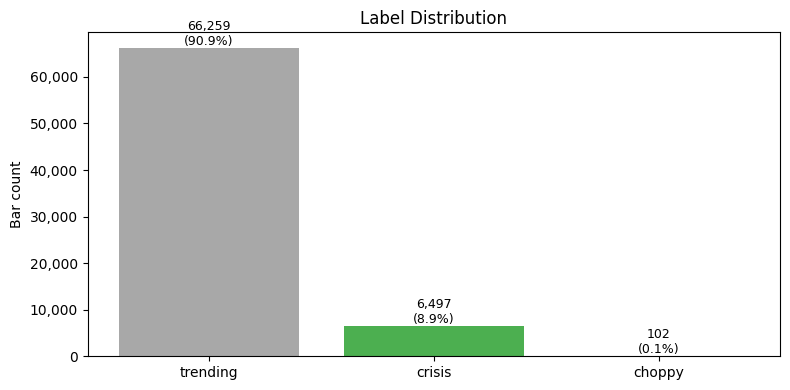

Note: choppy dominates — class_weight="balanced" corrects for this during training


In [18]:
# ── Compute labels ─────────────────────────────────────────────────────────────
LABEL_MAP = {0: 'mean_reverting', 1: 'choppy', 2: 'trending', 3: 'crisis'}
COLORS    = {0: '#4e9af1', 1: '#a8a8a8', 2: '#4caf50', 3: '#f44336'}

def compute_labels(df: pd.DataFrame, feat: pd.DataFrame) -> pd.Series:
    hurst = feat['hurst'].fillna(0.5)
    vol   = feat['realized_vol_20']

    labels = pd.Series(1, index=df.index, dtype=int)
    labels[hurst < 0.45] = 0
    labels[hurst > 0.55] = 2

    vm = vol.rolling(60, min_periods=20).mean()
    vs = vol.rolling(60, min_periods=20).std()
    labels[vol > (vm + 2.0 * vs)] = 3  # crisis override

    return labels


labels = compute_labels(df_raw, features)

# Distribution plot
dist = labels.map(LABEL_MAP).value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(dist.index, dist.values,
              color=[COLORS[k] for k, v in LABEL_MAP.items() if v in dist.index])
for bar, val in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}\n({val/len(labels):.1%})', ha='center', va='bottom', fontsize=9)
ax.set_title('Label Distribution')
ax.set_ylabel('Bar count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print('Note: choppy dominates — class_weight="balanced" corrects for this during training')

In [19]:
# ── Build X, y — drop NaN rows from rolling warm-up ───────────────────────────
valid = features.notna().all(axis=1)
X = features[valid]
y = labels[valid]

print(f'Training set: {len(X):,} bars  ({valid.sum()/len(valid):.1%} of raw data)')
print(f'Features:     {list(X.columns)}')
print(f'Dropped (NaN warm-up): {(~valid).sum():,} bars')

Training set: 72,753 bars  (99.9% of raw data)
Features:     ['realized_vol_5', 'log_return_5', 'realized_vol_20', 'log_return_20', 'realized_vol_60', 'log_return_60', 'rsi_14', 'rsi_14_zscore', 'rsi_14_dev50', 'volume_zscore_60', 'price_range_norm', 'hurst']
Dropped (NaN warm-up): 105 bars


## 4 — Walk-Forward Cross-Validation

Standard random k-fold CV **leaks future data** into training when your features include rolling windows.
Walk-forward CV trains strictly on past data and validates on future data — exactly how the model will be used in production.

```
Fold 1:  [═══train═══]  gap  [═test═]
Fold 2:  [═════train══════]  gap  [═test═]
Fold 3:  [════════train═══════]  gap  [═test═]
         ...expanding window...
```

The **gap=60 bars** (1 hour) prevents leakage from 60-bar rolling features like `realized_vol_60`.

In [1]:
# ── Walk-forward CV ────────────────────────────────────────────────────────────
# test_size=2016 ≈ 1 trading week (6.5h × 60m × 5.2 avg days/week)
tscv = TimeSeriesSplit(n_splits=8, gap=60, test_size=2016)

pipe = Pipeline([
    ('scaler', RobustScaler()),     # robust to vol spikes — ignores extreme outliers
    ('clf', LGBMClassifier(
        n_estimators=500,
        num_leaves=31,
        learning_rate=0.1,
        min_child_samples=20,
        class_weight='balanced',   # prevents choppy class from dominating
        verbose=-1,
    )),
])

# CalibratedClassifierCV converts raw LightGBM scores → proper probabilities.
# Without this, regimeConfidence=0.9 does NOT mean "90% accurate".
# With isotonic calibration it does (roughly).
# Note: cv=2 is used instead of 5 to avoid ValueError on small datasets
# where a minority class (like 'crisis') has very few examples in a fold.
calibrated = CalibratedClassifierCV(pipe, method='isotonic', cv=2)

print('Running 8-fold walk-forward CV...')
cv_results = cross_validate(
    calibrated, X, y, cv=tscv,
    scoring=['roc_auc_ovr_weighted', 'f1_weighted'],
    verbose=1,
)

mean_auc = cv_results['test_roc_auc_ovr_weighted'].mean()
mean_f1  = cv_results['test_f1_weighted'].mean()

print(f'\n═══ CV Results (8-fold walk-forward) ═══')
print(f'  ROC-AUC weighted OvR : {mean_auc:.4f}  (per fold: {cv_results["test_roc_auc_ovr_weighted"].round(3)})')
print(f'  F1 weighted           : {mean_f1:.4f}  (per fold: {cv_results["test_f1_weighted"].round(3)})')
print()
print('Guide: AUC > 0.65 = reasonable, > 0.75 = good, > 0.85 = excellent')

NameError: name 'TimeSeriesSplit' is not defined

In [ ]:
# ── Plot fold-by-fold performance ─────────────────────────────────────────────
folds = range(1, 9)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(folds, cv_results['test_roc_auc_ovr_weighted'], 'o-', label='ROC-AUC', color='steelblue')
ax.plot(folds, cv_results['test_f1_weighted'], 's--', label='F1 weighted', color='darkorange')
ax.axhline(mean_auc, color='steelblue', linestyle=':', alpha=0.5, label=f'Mean AUC={mean_auc:.3f}')
ax.axhline(mean_f1,  color='darkorange', linestyle=':', alpha=0.5, label=f'Mean F1={mean_f1:.3f}')
ax.set_xlabel('Fold (chronological)')
ax.set_ylabel('Score')
ax.set_title('Walk-Forward CV — Score per Fold')
ax.set_xticks(folds)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print('Flat/stable line = model generalises across time periods')
print('Declining line    = model overfits early data (increase regularisation)')

## 5 — (Optional) Optuna Hyperparameter Search

Run this section only if CV metrics above are below **0.65 AUC**.
Adds ~30 minutes but can meaningfully improve a weak baseline.

Skip if metrics are already good — more trials do not guarantee better production performance.

In [ ]:
# ── Optuna hyperparameter search (OPTIONAL — skip if AUC > 0.65) ──────────────
RUN_OPTUNA = False   # ← set True to enable

best_params = {}

if RUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
            'num_leaves':        trial.suggest_int('num_leaves', 15, 63),
            'max_depth':         trial.suggest_int('max_depth', 4, 10),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 1.0),
            'class_weight': 'balanced',
            'verbose': -1,
        }
        p = Pipeline([('scaler', RobustScaler()), ('clf', LGBMClassifier(**params))])
        cv = cross_validate(p, X, y, cv=tscv, scoring='f1_weighted')
        return cv['test_score'].mean()

    study = optuna.create_study(direction='maximize', study_name=f'{SYMBOL}-regime')
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    best_params = study.best_params
    print(f'Best F1:     {study.best_value:.4f}')
    print(f'Best params: {best_params}')

    # Rebuild pipeline with best params
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('clf', LGBMClassifier(**best_params, class_weight='balanced', verbose=-1)),
    ])
    calibrated = CalibratedClassifierCV(pipe, method='isotonic', cv=5)
else:
    print('Optuna skipped. Set RUN_OPTUNA = True to enable.')

## 6 — Final Fit & Evaluation

In [ ]:
# ── Final fit on all available data ───────────────────────────────────────────
print('Fitting final model on full dataset...')
calibrated.fit(X, y)
print('Done')

In [ ]:
# ── Evaluate on a held-out final window (last 4 weeks) ────────────────────────
# This is informational only — the real evaluation is the walk-forward CV above.
holdout_n  = 2016 * 4  # ~4 trading weeks
X_hold = X.iloc[-holdout_n:]
y_hold = y.iloc[-holdout_n:]
y_pred = calibrated.predict(X_hold)

target_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]
print('═══ Classification Report (last 4 weeks holdout) ═══')
print(classification_report(y_hold, y_pred, target_names=target_names, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_hold, y_pred,
    display_labels=target_names,
    cmap='Blues', ax=ax,
)
ax.set_title('Confusion Matrix — Holdout (last 4 weeks)')
plt.tight_layout()
plt.show()

In [ ]:
# ── Feature importance ─────────────────────────────────────────────────────────
# Extract the LightGBM base estimator from inside the calibrated pipeline.
# CalibratedClassifierCV wraps multiple estimators — average their importances.
try:
    importances = np.zeros(len(X.columns))
    count = 0
    for est in calibrated.calibrated_classifiers_:
        lgbm = est.estimator.named_steps['clf']
        importances += lgbm.feature_importances_
        count += 1
    importances /= count

    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Feature Importance (LightGBM — averaged across calibration folds)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Could not extract feature importances: {e}')

## 7 — Save to Google Drive

In [ ]:
# ── Save model + metadata to Drive ────────────────────────────────────────────
timestamp  = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path = Path(SAVE_DIR) / f'{SYMBOL}_regime_classifier_{timestamp}.pkl'
meta_path  = model_path.with_suffix('.json')

with open(model_path, 'wb') as f:
    pickle.dump(calibrated, f)

meta = {
    'symbol':                 SYMBOL,
    'trained_at':             timestamp,
    'train_start':            START_DATE,
    'train_end':              END_DATE,
    'n_samples':              len(X),
    'feature_schema_version': '1.0.0',
    'feature_columns':        list(X.columns),
    'cv_mean_roc_auc':        round(float(mean_auc), 4),
    'cv_mean_f1':             round(float(mean_f1), 4),
    'optuna_best_params':     best_params if best_params else None,
}
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Model saved → {model_path}')
print(f'Meta  saved → {meta_path}')
print()
print('Next step: download from Drive and run register_model.py on your OPC server')
print(f'  Model filename: {model_path.name}')
print()
print(json.dumps(meta, indent=2))

## 8 — Register on OPC Server

After downloading the `.pkl` from Google Drive:

```bash
# On your OPC server
cd /home/opc/projects/trade-bot/market-dashboard/backend

uv run python notebooks/register_model.py \
    --model-path /path/to/SPY_regime_classifier_YYYYMMDD_HHMMSS.pkl \
    --meta-path  /path/to/SPY_regime_classifier_YYYYMMDD_HHMMSS.json

# Then restart ml-api to load the new champion
docker-compose -f ../docker-compose.yaml -f ../docker-compose.app.yaml restart ml-api
```

Open MLflow UI at http://localhost:5000 to verify the `@champion` alias was set.